# hw4 - NN pyTorch

Во всем задании вы должны работать со входом из строк размером (длиной) 1024

## Часть 1 Фурье

### Подготовка данных

Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from scipy.signal import periodogram
import matplotlib.pyplot as plt
import random

# фиксируем случайность
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass
N = 1024

# Генерация синусоидальных сигналов и разметки (DFT)
def generate_signals(batch_size, n: int = N, num_sines_range=(1, 5), noise_std: float = 0.02) -> np.ndarray:
    t = np.arange(n) / n
    signals = np.zeros((batch_size, n), dtype=np.float32)
    for i in range(batch_size):
        k = np.random.randint(num_sines_range[0], num_sines_range[1] + 1)
        x = np.zeros(n, dtype=np.float32)
        used_freqs = set()
        for _ in range(k):
            f = np.random.randint(1, n // 2)  # дискретные частоты
            if f in used_freqs:
                continue
            used_freqs.add(f)
            amp = np.random.uniform(0.3, 1.0)
            phase = np.random.uniform(0.0, 2 * np.pi)
            x += (amp * np.sin(2 * np.pi * f * t + phase)).astype(np.float32)
        if noise_std > 0:
            x += np.random.normal(0.0, noise_std, size=n).astype(np.float32)
        signals[i] = x
    return signals

def fft_targets(signals: np.ndarray) -> np.ndarray:
    F = np.fft.fft(signals, axis=1)
    y = np.concatenate([F.real, F.imag], axis=1).astype(np.float32)
    return y

# датасеты для задачи DFT
num_train, num_val = 12000, 2000
X_all = generate_signals(num_train + num_val, N)
Y_all = fft_targets(X_all)

X_tensor = torch.from_numpy(X_all)
Y_tensor = torch.from_numpy(Y_all)

dset_fft = TensorDataset(X_tensor, Y_tensor)
dtrain_fft, dval_fft = random_split(dset_fft, [num_train, num_val], generator=torch.Generator().manual_seed(42))

train_loader_fft = DataLoader(dtrain_fft, batch_size=256, shuffle=True, drop_last=False, num_workers=2, pin_memory=(device!='cpu'))
val_loader_fft = DataLoader(dval_fft, batch_size=256, shuffle=False, drop_last=False, num_workers=2, pin_memory=(device!='cpu'))


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье

In [8]:
# НС для DFT: линейная модель (DFT — линейное преобразование)
class DFTNet(nn.Module):
    def __init__(self, n: int):
        super().__init__()
        self.linear = nn.Linear(n, 2 * n, bias=False)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)

model_fft = DFTNet(N).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_fft.parameters(), lr=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=3, min_lr=1e-4)

def evaluate_mse(loader):
    model_fft.eval()
    total_loss = 0.0
    num = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model_fft(xb)
            loss = criterion(pred, yb)
            total_loss += loss.item() * xb.size(0)
            num += xb.size(0)
    return total_loss / max(1, num)

best_val = float('inf')
best_state = None
epochs = 20
for epoch in range(1, epochs + 1):
    model_fft.train()
    running = 0.0
    seen = 0
    for xb, yb in train_loader_fft:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model_fft(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
        seen += xb.size(0)
    train_mse = running / max(1, seen)
    val_mse = evaluate_mse(val_loader_fft)
    scheduler.step(val_mse)
    if val_mse < best_val:
        best_val = val_mse
        best_state = {k: v.detach().cpu().clone() for k, v in model_fft.state_dict().items()}
    print(f"Эпоха {epoch:02d}: train_mse={train_mse:.6e}, val_mse={val_mse:.6e}")

if best_state is not None:
    model_fft.load_state_dict(best_state)


/Users/catmorozz/Documents/GitHub/MIPT_ML_base/mipt_ml/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Эпоха 01: train_mse=2.810822e+02, val_mse=2.061013e+02
Эпоха 02: train_mse=1.503213e+02, val_mse=1.118615e+02
Эпоха 03: train_mse=7.568860e+01, val_mse=5.736637e+01
Эпоха 04: train_mse=3.579116e+01, val_mse=2.788036e+01
Эпоха 05: train_mse=1.600596e+01, val_mse=1.284081e+01
Эпоха 06: train_mse=6.826683e+00, val_mse=5.648776e+00
Эпоха 07: train_mse=2.797206e+00, val_mse=2.397760e+00
Эпоха 08: train_mse=1.110520e+00, val_mse=9.832548e-01
Эпоха 09: train_mse=4.295271e-01, val_mse=3.904429e-01
Эпоха 10: train_mse=1.624127e-01, val_mse=1.516214e-01
Эпоха 11: train_mse=6.043809e-02, val_mse=5.722428e-02
Эпоха 12: train_mse=2.223685e-02, val_mse=2.141281e-02
Эпоха 13: train_mse=8.302537e-03, val_mse=8.049002e-03
Эпоха 14: train_mse=3.280848e-03, val_mse=3.221794e-03
Эпоха 15: train_mse=1.515034e-03, val_mse=1.492213e-03
Эпоха 16: train_mse=9.103545e-04, val_mse=8.891350e-04
Эпоха 17: train_mse=7.147239e-04, val_mse=7.242780e-04
Эпоха 18: train_mse=6.498228e-04, val_mse=6.636161e-04
Эпоха 19: 

### Сравните свое решение с пакетным методом

MSE по вал. батчу (DFT, все компоненты): 6.631832e-04


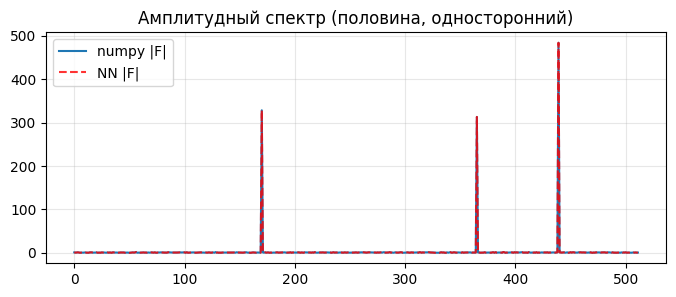

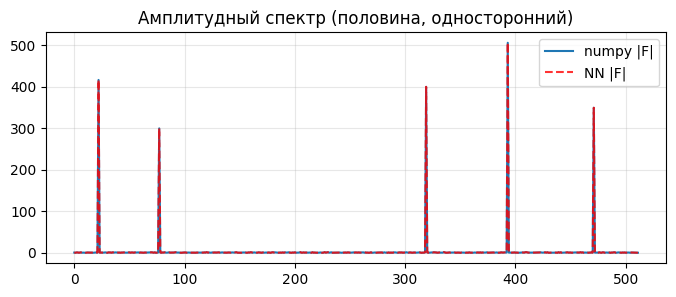

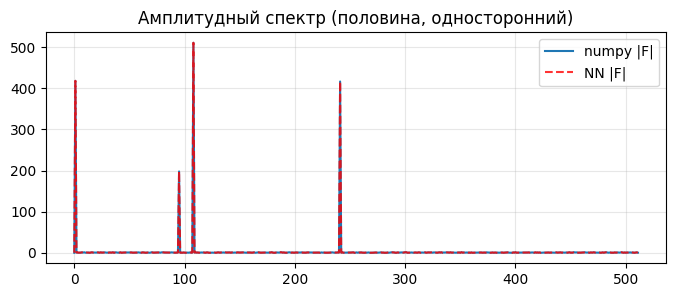

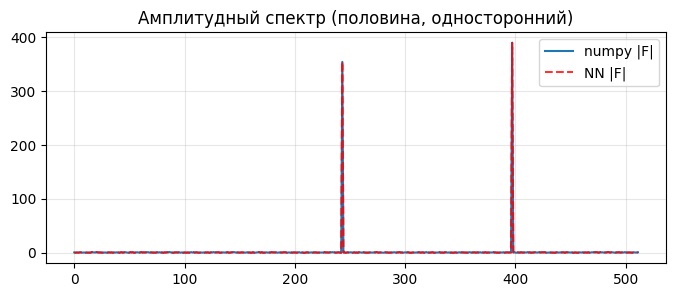

In [22]:
# Сравнение амплитудных спектров (|F|) с numpy.fft
model_fft.eval()
with torch.no_grad():
    xb, yb = next(iter(DataLoader(dval_fft, batch_size=4, shuffle=True)))
    xb = xb.to(device)
    pred = model_fft(xb).cpu().numpy()

true = yb.numpy()
pred_real = pred[:, :N]
pred_imag = pred[:, N:]
pred_complex = pred_real + 1j * pred_imag

true_real = true[:, :N]
true_imag = true[:, N:]
true_complex = true_real + 1j * true_imag

mse_batch = np.mean((pred - true) ** 2)
print(f"MSE по вал. батчу (DFT, все компоненты): {mse_batch:.6e}")

for i in range(min(4, xb.size(0))):
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    ax.plot(np.abs(true_complex[i, :N//2]), label='numpy |F|')
    ax.plot(np.abs(pred_complex[i, :N//2]), label='NN |F|', alpha=0.8, ls='--', color='red')
    ax.set_title("Амплитудный спектр (половина, односторонний)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if i == 0:
        fig.savefig('amplit.png', dpi=150, bbox_inches='tight')
    plt.show()


Ну вроде довольно хорошо получилось, я визуально даже не виду расхождений

In [10]:
# Количественная оценка качества по вал. выборке (DFT)
model_fft.eval()
all_true = []
all_pred = []
with torch.no_grad():
    for xb, yb in val_loader_fft:
        xb = xb.to(device)
        pred = model_fft(xb).cpu().numpy()
        all_pred.append(pred)
        all_true.append(yb.numpy())
all_true = np.concatenate(all_true, axis=0)
all_pred = np.concatenate(all_pred, axis=0)

mse_all = np.mean((all_pred - all_true) ** 2)
mt = np.sqrt(all_true[:, :N] ** 2 + all_true[:, N:] ** 2)[:, :N//2]
mp = np.sqrt(all_pred[:, :N] ** 2 + all_pred[:, N:] ** 2)[:, :N//2]
rel_l2 = np.linalg.norm(mp - mt, axis=1) / (np.linalg.norm(mt, axis=1) + 1e-12)
cos_sim = np.sum(mp * mt, axis=1) / ((np.linalg.norm(mp, axis=1) * np.linalg.norm(mt, axis=1)) + 1e-12)
print(f"DFT: MSE(all)={mse_all:.6e}, relL2(|F|)={rel_l2.mean():.6e}, cos(|F|)={cos_sim.mean():.6f}")


DFT: MSE(all)=6.087591e-04, relL2(|F|)=7.576019e-04, cos(|F|)=0.999999


## Часть 2 Power spectral density (dB)

### Подготовка данных

Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.

In [11]:
# Подготовка данных для PSD (dB) на основе векторизованного rFFT

def compute_psd_db(signals: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    S = np.fft.rfft(signals, axis=1)
    P = (np.abs(S) ** 2) / N
    P_db = 10.0 * np.log10(P + eps)
    return P_db[:, :-1].astype(np.float32)

num_train_psd, num_val_psd = 8000, 2000
X_all_psd = generate_signals(num_train_psd + num_val_psd, N, num_sines_range=(1, 6), noise_std=0.03)
Y_all_psd = compute_psd_db(X_all_psd)

X_psd = torch.from_numpy(X_all_psd)
Y_psd = torch.from_numpy(Y_all_psd)

# стандартизация по train-части
Y_psd_mean = Y_psd[:num_train_psd].mean(dim=0)
Y_psd_std = Y_psd[:num_train_psd].std(dim=0)
Y_psd_std = torch.clamp(Y_psd_std, min=1e-6)
Y_psd_z = (Y_psd - Y_psd_mean) / Y_psd_std

dset_psd = TensorDataset(X_psd, Y_psd_z)
dtrain_psd, dval_psd = random_split(dset_psd, [num_train_psd, num_val_psd], generator=torch.Generator().manual_seed(7))

train_loader_psd = DataLoader(dtrain_psd, batch_size=256, shuffle=True, drop_last=False, num_workers=2, pin_memory=(device!='cpu'))
val_loader_psd = DataLoader(dval_psd, batch_size=256, shuffle=False, drop_last=False, num_workers=2, pin_memory=(device!='cpu'))


### Соберите и обучите нейросеть для предсказания спектральной плотности мощности

*Подсказка: для входа 1024 выход будет 512*

In [12]:
# НС для PSD: нелинейная аппроксимация (модуль квадрата спектра)
class PSDNet(nn.Module):
    def __init__(self, n_in: int, n_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 1024),
            nn.ReLU(),
            nn.Linear(1024, n_out),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

model_psd = PSDNet(N, 512).to(device)
crit_psd = nn.MSELoss()
opt_psd = optim.Adam(model_psd.parameters(), lr=1e-3)
sched_psd = optim.lr_scheduler.ReduceLROnPlateau(opt_psd, factor=0.5, patience=5, min_lr=1e-5)

def eval_psd(loader):
    model_psd.eval()
    total = 0.0
    num = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred = model_psd(xb)
            loss = crit_psd(pred, yb)
            total += loss.item() * xb.size(0)
            num += xb.size(0)
    return total / max(1, num)

best_val = float('inf')
best_state = None
epochs = 30
for epoch in range(1, epochs + 1):
    model_psd.train()
    run = 0.0
    seen = 0
    for xb, yb in train_loader_psd:
        xb = xb.to(device)
        yb = yb.to(device)
        opt_psd.zero_grad()
        pred = model_psd(xb)
        loss = crit_psd(pred, yb)
        loss.backward()
        opt_psd.step()
        run += loss.item() * xb.size(0)
        seen += xb.size(0)
    tr = run / max(1, seen)
    vl = eval_psd(val_loader_psd)
    sched_psd.step(vl)
    if vl < best_val:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in model_psd.state_dict().items()}
    print(f"Эпоха {epoch:02d}: train_mse={tr:.6e}, val_mse={vl:.6e}")

if best_state is not None:
    model_psd.load_state_dict(best_state)


Эпоха 01: train_mse=1.026737e+00, val_mse=1.002452e+00
Эпоха 02: train_mse=9.329051e-01, val_mse=9.974134e-01
Эпоха 03: train_mse=8.793419e-01, val_mse=1.001404e+00
Эпоха 04: train_mse=8.295937e-01, val_mse=1.009771e+00
Эпоха 05: train_mse=7.850291e-01, val_mse=1.018949e+00
Эпоха 06: train_mse=7.463042e-01, val_mse=1.028107e+00
Эпоха 07: train_mse=7.126548e-01, val_mse=1.036528e+00
Эпоха 08: train_mse=6.843752e-01, val_mse=1.044758e+00
Эпоха 09: train_mse=6.431618e-01, val_mse=1.046040e+00
Эпоха 10: train_mse=6.285236e-01, val_mse=1.051574e+00
Эпоха 11: train_mse=6.165674e-01, val_mse=1.056792e+00
Эпоха 12: train_mse=6.058408e-01, val_mse=1.061710e+00
Эпоха 13: train_mse=5.959548e-01, val_mse=1.066756e+00
Эпоха 14: train_mse=5.867976e-01, val_mse=1.072022e+00
Эпоха 15: train_mse=5.699830e-01, val_mse=1.073082e+00
Эпоха 16: train_mse=5.649988e-01, val_mse=1.075881e+00
Эпоха 17: train_mse=5.606342e-01, val_mse=1.078836e+00
Эпоха 18: train_mse=5.566472e-01, val_mse=1.081712e+00
Эпоха 19: 

### Провалидируйте свое решение

*Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением*

/Users/catmorozz/Documents/GitHub/MIPT_ML_base/mipt_ml/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


MSE(all, PSD dB) = 4.979889e+01


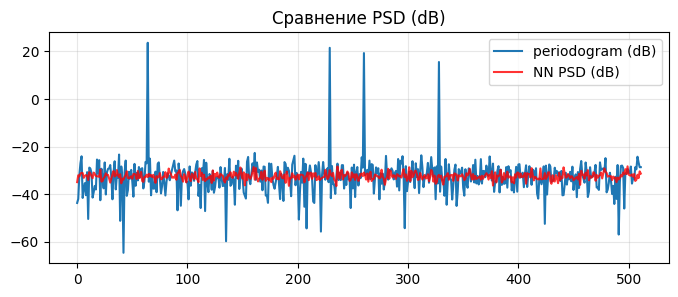

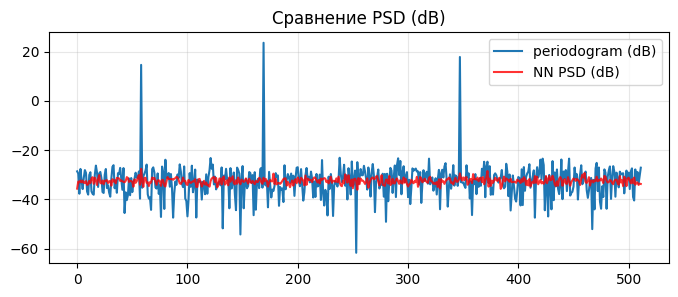

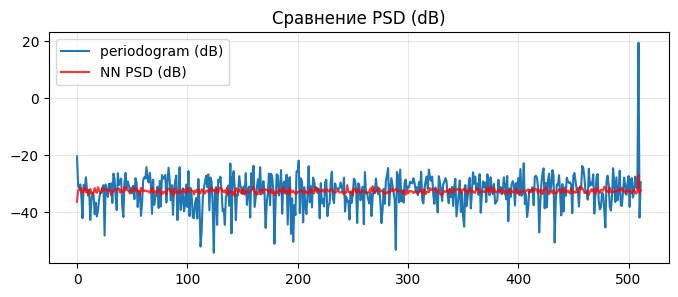

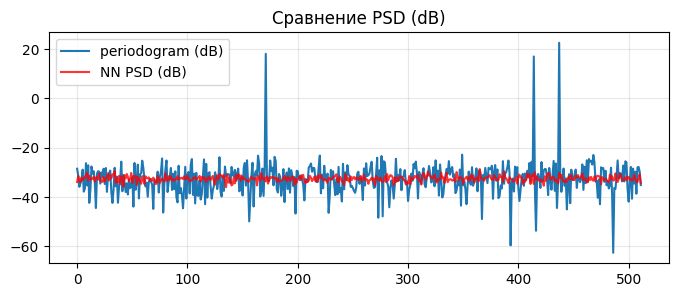

In [23]:
# Валидация: сравнение предсказаний PSD с пакетным решением
# метрика по всей валидации (в dB-пространстве)
model_psd.eval()
all_true = []
all_pred = []
with torch.no_grad():
    for xb, yb in val_loader_psd:
        xb = xb.to(device)
        pred_z = model_psd(xb).cpu().numpy()
        pred_db = pred_z * Y_psd_std.numpy() + Y_psd_mean.numpy()
        all_pred.append(pred_db)
        all_true.append(yb.numpy() * Y_psd_std.numpy() + Y_psd_mean.numpy())
all_true = np.concatenate(all_true, axis=0)
all_pred = np.concatenate(all_pred, axis=0)
print(f"MSE(all, PSD dB) = {np.mean((all_pred - all_true)**2):.6e}")

# визуализация нескольких примеров и сохранение
with torch.no_grad():
    xb, yb = next(iter(DataLoader(dval_psd, batch_size=4, shuffle=True)))
    xb = xb.to(device)
    pred_z = model_psd(xb).cpu().numpy()
    pred = pred_z * Y_psd_std.numpy() + Y_psd_mean.numpy()
true = yb.numpy() * Y_psd_std.numpy() + Y_psd_mean.numpy()

for i in range(min(4, true.shape[0])):
    fig, ax = plt.subplots(1, 1, figsize=(8, 3))
    ax.plot(true[i], label='periodogram (dB)')
    ax.plot(pred[i], label='NN PSD (dB)', alpha=0.8, color='red')
    ax.set_title("Сравнение PSD (dB)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if i == 0:
        fig.savefig('psd.png', dpi=150, bbox_inches='tight')
    plt.show()


Форма спектров совпадает, пики на тех же частотах. На пиках как-то не выходит, но думаю это связано с тем, что мы минимизируем mse и точ-в-точ мы никак не попадём